# HELD → Phonopy dispersion for non-magnetic BCC Fe

This notebook converts the complete HELD force-constant tensors into a Phonopy-ready folder and calculates the BCC Fe dispersion along Γ–H–N–Γ–P–H. It supports either the trajectory-mean force constants or any stored MD step.

Each output folder contains `POSCAR`, `FORCE_CONSTANTS`, `band.conf`, `band.yaml`, numerical dispersion files, a plot, and provenance metadata. The conversion explicitly maps AIMD atom order to Phonopy supercell order and validates Phonopy frequencies against HELD's internal dynamical matrix.

In [2]:
%pip install phonopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.1/718.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.4/972.4 kB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [phonopy]m2/3 [phonopy]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

CWD = Path.cwd().resolve()
FC_DIR = CWD if (CWD / 'phonopy_bcc_workflow.py').is_file() else CWD / 'ForceConstants'
if not FC_DIR.is_dir():
    raise FileNotFoundError('Run from IronCoreMD/ForceConstants or the IronCoreMD root')
if str(FC_DIR) not in sys.path:
    sys.path.insert(0, str(FC_DIR))
from phonopy_bcc_workflow import PHONOPY_ROOT, RESULTS_ROOT, export_and_run

INDEX_NPZ = RESULTS_ROOT / 'bcc_held_5nn_index.npz'
print('HELD results:', RESULTS_ROOT)
print('Phonopy folders:', PHONOPY_ROOT)

HELD results: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results
Phonopy folders: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy


## 1. Available completed HELD cases

In [3]:
with np.load(INDEX_NPZ, allow_pickle=False) as index:
    cases = pd.DataFrame({
        'case_id': index['case_id'].astype(str),
        'status': index['status'].astype(str),
        'n_frames': index['n_frames'],
        'source_path': index['source_path'].astype(str),
        'result_path': index['output_path'].astype(str),
        'error': index['error'].astype(str),
    })
completed = cases[cases.status.isin(['completed', 'cached'])].reset_index(drop=True)
print(f'Completed: {len(completed)} / {len(cases)}')
display(completed)
display(cases[cases.status == 'failed'])

Completed: 137 / 138


,case_id,status,n_frames,source_path,result_path,error
0,2_29_4000K__43ee4c4f,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
1,2_29_4500K__ed36d84b,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
2,2_29_5000K__e8b3ab4b,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
3,2_29_5500K__433f7228,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
4,2_29_6000K__56191404,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
...,...,...,...,...,...,...
132,2_55_4000K__3b01b60f,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
133,2_55_4500K__f2bb4b5e,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
134,2_55_5000K__49ac84d1,completed,399,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,
135,2_55_5500K__4a3c421d,completed,162,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,


,case_id,status,n_frames,source_path,result_path,error
57,2_40_5000K_disp__7e1101ee,failed,0,/Users/dajuarez4/Documents/Fe/IronCoreMD/datas...,/Users/dajuarez4/Documents/Fe/IronCoreMD/Force...,ValueError: Could not map supercell atom at pr...


## 2. Select the case and force constants

Set `CASE_ID` from the table. Use `MD_STEP = None` for the trajectory mean, or assign an actual value from `step_ids` to calculate an instantaneous MD-step dispersion.

In [4]:
CASE_ID = '2_29_4000K__43ee4c4f'
MD_STEP = None  # Example: 1; None uses the trajectory-mean FCs
POINTS_PER_SEGMENT = 101

matches = completed[completed.case_id == CASE_ID]
if len(matches) != 1:
    raise KeyError(f'Expected one completed case {CASE_ID!r}; found {len(matches)}')
result_npz = Path(matches.iloc[0].result_path)
if not result_npz.is_file():
    result_npz = RESULTS_ROOT / result_npz.name
if not result_npz.is_file():
    raise FileNotFoundError(result_npz)
with np.load(result_npz, allow_pickle=False) as result:
    available_steps = result['step_ids'].astype(int)
print('Result:', result_npz)
print('Stored MD steps:', available_steps[:5], '...', available_steps[-5:])

Result: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results/2_29_4000K__43ee4c4f_held_5nn.npz
Stored MD steps: [1 2 3 4 5] ... [395 396 397 398 399]


[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

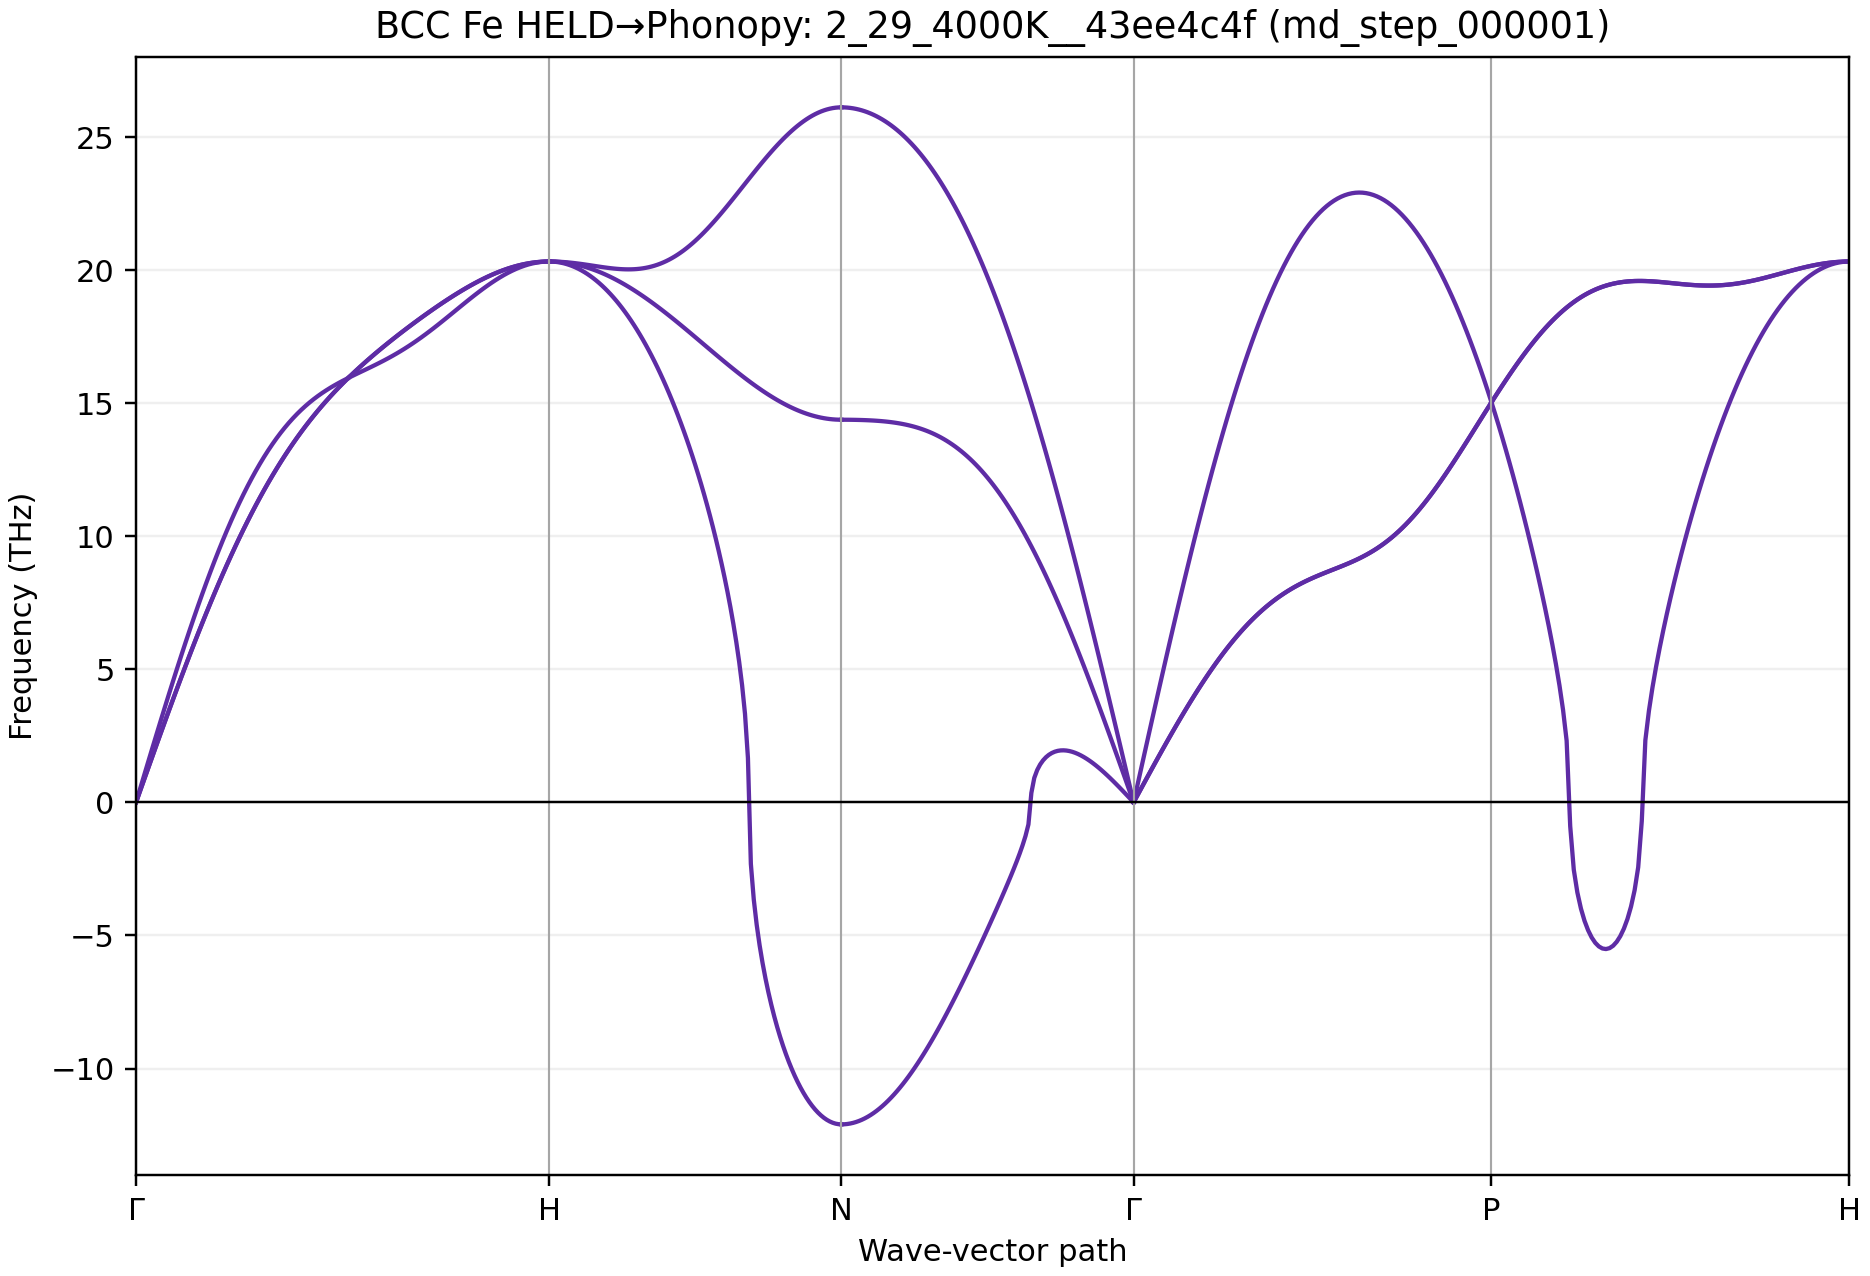

In [5]:
print(available_steps)  # Actual MD step IDs you can select

MD_STEP = int(available_steps[0])  # First stored step; change as desired

summary = export_and_run(
    result_npz,
    md_step=MD_STEP,
    points_per_segment=101,
    validate_against_held=True,
)

output_dir = Path(summary["output_directory"])
print(output_dir)
display(Image(filename=str(output_dir / "phonon_dispersion.png")))

In [6]:
for step in available_steps:
    summary = export_and_run(
        result_npz,
        md_step=int(step),
        points_per_segment=101,
        validate_against_held=True,
    )
    print(f"Step {step}: {summary['output_directory']}")

Step 1: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000001
Step 2: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000002
Step 3: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000003
Step 4: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000004
Step 5: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000005
Step 6: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000006
Step 7: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000007
Step 8: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000008
Step 9: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/md_step_000009
Step 10: /Users/dajuarez4/Do

## 3. Create the Phonopy folder and calculate the dispersion

In [4]:
summary = export_and_run(
    result_npz,
    md_step=MD_STEP,
    points_per_segment=POINTS_PER_SEGMENT,
    validate_against_held=True,
)
summary

{'case_id': '2_29_4000K__43ee4c4f',
 'source_result_npz': '/Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/results/2_29_4000K__43ee4c4f_held_5nn.npz',
 'source_trajectory_npz': '/Users/dajuarez4/Documents/Fe/IronCoreMD/dataset/bcc/non-mag/2.29_4000K.npz',
 'selection': 'mean',
 'md_step': None,
 'phase': 'bcc',
 'symbol': 'Fe',
 'natoms_supercell': 128,
 'supercell_matrix': [[0, 4, 4], [4, 0, 4], [4, 4, 0]],
 'phonopy_to_dataset_atom_map': [0,
  67,
  23,
  86,
  42,
  105,
  61,
  124,
  76,
  16,
  83,
  39,
  102,
  58,
  121,
  13,
  29,
  92,
  32,
  99,
  55,
  118,
  10,
  73,
  89,
  45,
  108,
  48,
  115,
  7,
  70,
  26,
  112,
  4,
  71,
  27,
  90,
  46,
  109,
  49,
  1,
  64,
  20,
  87,
  43,
  106,
  62,
  125,
  77,
  17,
  80,
  36,
  103,
  59,
  122,
  14,
  30,
  93,
  33,
  96,
  52,
  119,
  11,
  74,
  53,
  116,
  8,
  75,
  31,
  94,
  34,
  97,
  113,
  5,
  68,
  24,
  91,
  47,
  110,
  50,
  2,
  65,
  21,
  84,
  40,
  107,
  63,
  126,
  78,
  1

Output directory: /Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/mean
HELD–Phonopy maximum difference (THz): 2.8100473379311097e-06


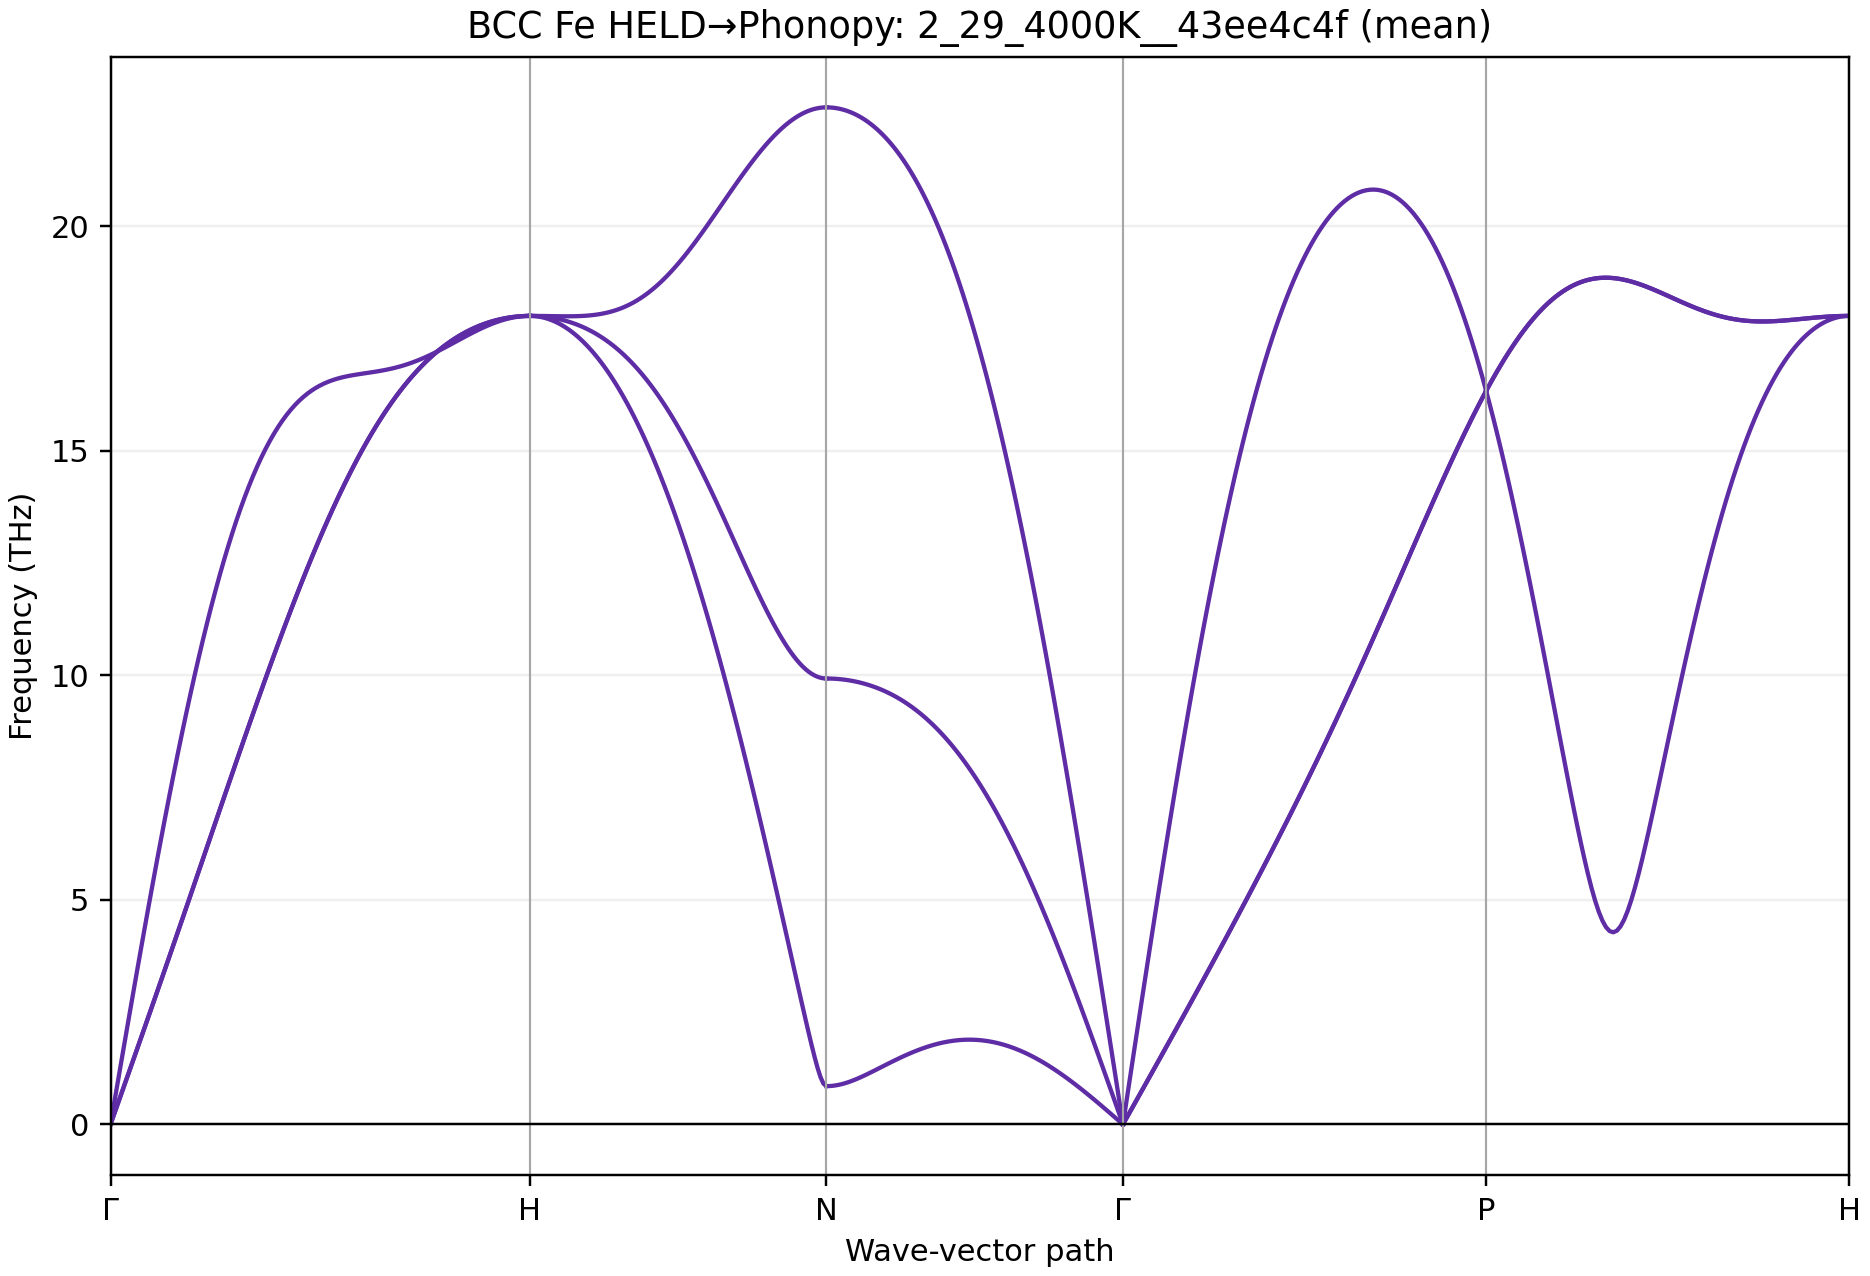

In [5]:
output_dir = Path(summary['output_directory'])
required = ['POSCAR', 'FORCE_CONSTANTS', 'band.conf', 'band.yaml', 'phonon_dispersion.npz', 'phonon_dispersion.dat', 'phonon_dispersion.png', 'metadata.json']
for name in required:
    assert (output_dir / name).is_file(), name
print('Output directory:', output_dir)
print('HELD–Phonopy maximum difference (THz):', summary['held_max_abs_delta_THz'])
display(Image(filename=str(output_dir / 'phonon_dispersion.png')))

## 4. Read the numerical dispersion

In [6]:
with np.load(output_dir / 'phonon_dispersion.npz', allow_pickle=False) as dispersion:
    qpoints = dispersion['qpoints']
    distances = dispersion['distances']
    frequencies_THz = dispersion['frequencies_THz']
    path_labels = dispersion['path_labels'].astype(str)
print('Path:', '–'.join(path_labels).replace('G', 'Γ'))
print('q-points shape:', qpoints.shape)
print('frequencies shape:', frequencies_THz.shape)
print('frequency range (THz):', float(frequencies_THz.min()), float(frequencies_THz.max()))

Path: Γ–H–N–Γ–P–H
q-points shape: (5, 101, 3)
frequencies shape: (5, 101, 3)
frequency range (THz): 1.522618866535818e-07 22.648861043319886


## 5. Optional: reproduce with the original Phonopy command

The Python workflow already ran Phonopy. This command reads the same folder layout as the original HELD workflow and recreates `band.yaml`, `band.pdf`, and `phonopy.yaml`.

In [7]:
print(f"cd '{output_dir}'")
print('/opt/anaconda3/bin/phonopy -p -s band.conf')

cd '/Users/dajuarez4/Documents/Fe/IronCoreMD/ForceConstants/phonopy/2_29_4000K__43ee4c4f/mean'
/opt/anaconda3/bin/phonopy -p -s band.conf


## 6. Optional batch calculation

Set `RUN_ALL_MEANS=True` to create a mean-dispersion folder for every completed trajectory. Existing output folders are safely regenerated because they contain derived products only.

In [8]:
RUN_ALL_MEANS = False
batch_summaries = []
if RUN_ALL_MEANS:
    for number, row in completed.iterrows():
        path = Path(row.result_path)
        if not path.is_file():
            path = RESULTS_ROOT / path.name
        print(f'[{number + 1}/{len(completed)}] {row.case_id}')
        batch_summaries.append(export_and_run(path, md_step=None, points_per_segment=POINTS_PER_SEGMENT))
    display(pd.DataFrame(batch_summaries))
else:
    print('Set RUN_ALL_MEANS=True to compute all completed mean dispersions.')

Set RUN_ALL_MEANS=True to compute all completed mean dispersions.
